In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
PLANT = 1
OUT = Path(r"C:\Users\VICTUS\Documents\College\Semester 3\Machine Learning\Solar Power Generation Data\processed")  # same folder as Stage 1
FIG = OUT.parents[1] / "figures"
FIG.mkdir(exist_ok=True)
 
df = pd.read_csv(OUT / f"plant{PLANT}_clean.csv", index_col="DATE_TIME", parse_dates=True)
TEST_START = pd.Timestamp("2020-06-11")

In [4]:
wx_nan = df["IRRADIATION"].isna()
print("Weather-NaN rows per day (days with any):")
print(wx_nan.groupby(df.index.date).sum().loc[lambda s: s > 0])
print(f"\nWeather-NaN rows in test period: {wx_nan[df.index >= TEST_START].sum()}")

Weather-NaN rows per day (days with any):
2020-05-15     3
2020-05-16     8
2020-05-20    16
2020-05-21    28
2020-05-23     5
2020-05-29    17
Name: IRRADIATION, dtype: int64

Weather-NaN rows in test period: 0


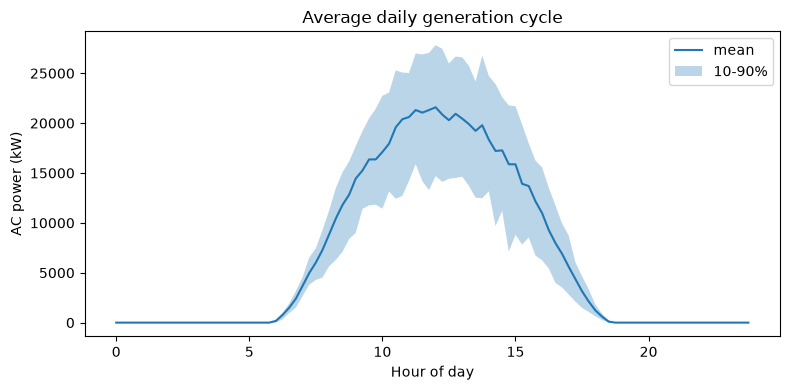

In [5]:
tod = df.index.hour + df.index.minute / 60
grp = df.groupby(tod)["AC_POWER"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grp.mean().index, grp.mean(), label="mean")
ax.fill_between(grp.mean().index, grp.quantile(0.1), grp.quantile(0.9), alpha=0.3, label="10-90%")
ax.set(xlabel="Hour of day", ylabel="AC power (kW)", title="Average daily generation cycle")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "eda_daily_cycle.png", dpi=150)

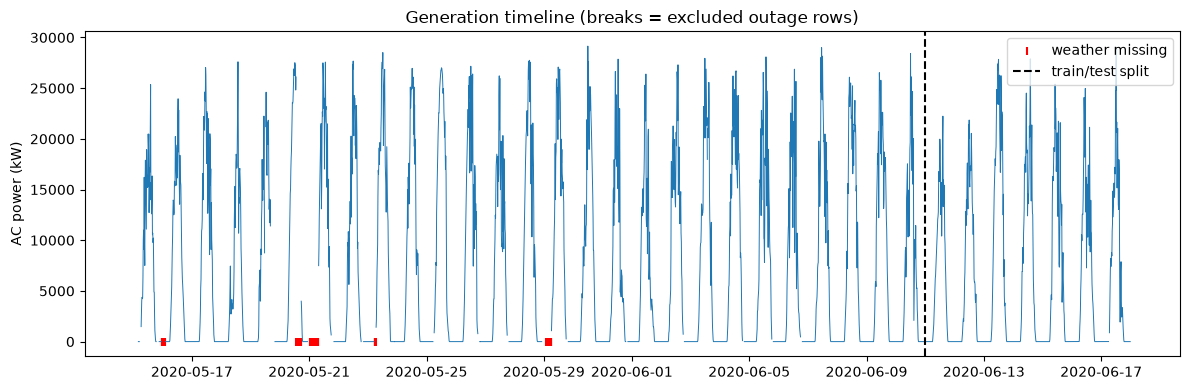

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["AC_POWER"], lw=0.7)
ax.scatter(df.index[wx_nan], [0] * wx_nan.sum(), marker="|", color="red", label="weather missing")
ax.axvline(TEST_START, color="k", ls="--", label="train/test split")
ax.set(ylabel="AC power (kW)", title="Generation timeline (breaks = excluded outage rows)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "eda_timeline.png", dpi=150)


Figures saved to C:\Users\VICTUS\Documents\College\Semester 3\Machine Learning\figures


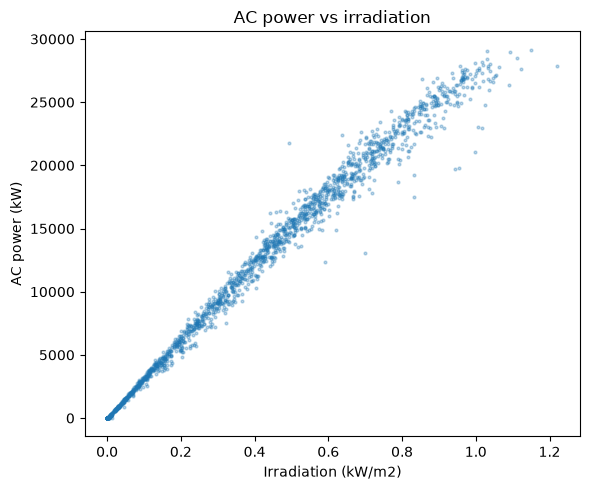

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["IRRADIATION"], df["AC_POWER"], s=4, alpha=0.3)
ax.set(xlabel="Irradiation (kW/m2)", ylabel="AC power (kW)", title="AC power vs irradiation")
fig.tight_layout()
fig.savefig(FIG / "eda_power_vs_irradiation.png", dpi=150)
 
print(f"\nFigures saved to {FIG}")